# Model Training, Evaluation, and Interpretability

This notebook trains and evaluates four neural network architectures of increasing complexity, then applies interpretability techniques to understand what the models have learned. The progression is intentional:

1. **MLP** — Establishes a baseline with a simple feedforward network
2. **RNN-LSTM** — Introduces sequential modeling to capture temporal patterns in the embedding space
3. **LSTM-Attention** — Adds an attention mechanism for dynamic feature weighting and interpretability
4. **BERT (fine-tuned)** — Leverages pre-trained language understanding with end-to-end fine-tuning

All models use binary cross-entropy loss, batch size 32, and 10 training epochs. We evaluate on **AUC-ROC** (robustness to class imbalance) and **F1-Score** (precision-recall balance).

In [1]:
import os
import sys
import string
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import seaborn as sns
import shutil

from scipy.stats import ttest_ind
from scipy.spatial.distance import cdist

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import sklearn
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import torch
import transformers
from transformers import BertTokenizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM, Layer, Reshape
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import SGD, Adam

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import lime
import lime.lime_tabular
import shap

# Add project root to path for local imports
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))

from words_of_war.data_utils import load_split_data
from words_of_war.models import AttentionLayer, build_mlp, build_lstm, build_lstm_attention
from words_of_war.evaluation import evaluate_binary_model
from words_of_war.plot_history import plot_training_history
from words_of_war.interpretability import (
    extract_attention_weights,
    analyze_attention_by_class,
    plot_attention_distribution,
    create_lime_explainer,
    create_shap_explainer,
)

/Users/wyattscott/Documents/WordsofWar/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Print versions
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("nltk:", nltk.__version__)
print("torch:", torch.__version__)
print("sklearn:", sklearn.__version__)
print("tensorflow:", tf.__version__)
print("transformers:", transformers.__version__)

numpy: 2.4.4
pandas: 3.0.2
nltk: 3.9.4
torch: 2.11.0
sklearn: 1.8.0
tensorflow: 2.21.0
transformers: 5.5.1


## Data Loading

We load the pre-computed BERT embeddings and labels from the Cleaning notebook. Each speech is represented as a 768-dimensional vector.

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = load_split_data('../data')

# Keep DataFrames for feature names (used by LIME)
X_train_df = pd.read_csv('../data/X_train.csv')

In [4]:
# Determine the input shape
input_shape = (X_train.shape[1:])

## Model 1: Multi-Layer Perceptron (MLP)

Our baseline model is a simple feedforward network. The MLP treats each speech embedding as an independent feature vector with no sequential structure — it can only learn from the overall distribution of features, not their relationships.

**Architecture choices:**
- 2 hidden layers (128 → 64 units) with ReLU activation and dropout (0.5) to prevent overfitting
- L2 regularization (λ=0.01) to penalize large weights
- SGD with Nesterov momentum (lr=0.001, momentum=0.99) — chosen over Adam for more stable convergence on this small dataset

In [5]:
# Build MLP model
model = build_mlp(input_dim=X_train.shape[1])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,753 (417.00 KB)

 Trainable params: 106,753 (417.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
opt = SGD(learning_rate=0.001, momentum=0.99, nesterov=True)

# Compile the model
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5037 - loss: 4.5733 - val_accuracy: 0.6356 - val_loss: 4.4382
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6267 - loss: 4.3705 - val_accuracy: 0.6271 - val_loss: 4.2597
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6575 - loss: 4.1477 - val_accuracy: 0.7119 - val_loss: 4.0089
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6670 - loss: 3.8863 - val_accuracy: 0.7288 - val_loss: 3.7147
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6660 - loss: 3.6158 - val_accuracy: 0.7712 - val_loss: 3.4108
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7232 - loss: 3.2777 - val_accuracy: 0.6695 - val_loss: 3.1194
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7508 - loss: 2.9793 - val_accuracy: 0.7458 - val_loss: 2.8096
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7922 - loss: 2.6737 - val_accuracy: 0.7288 - val_loss:

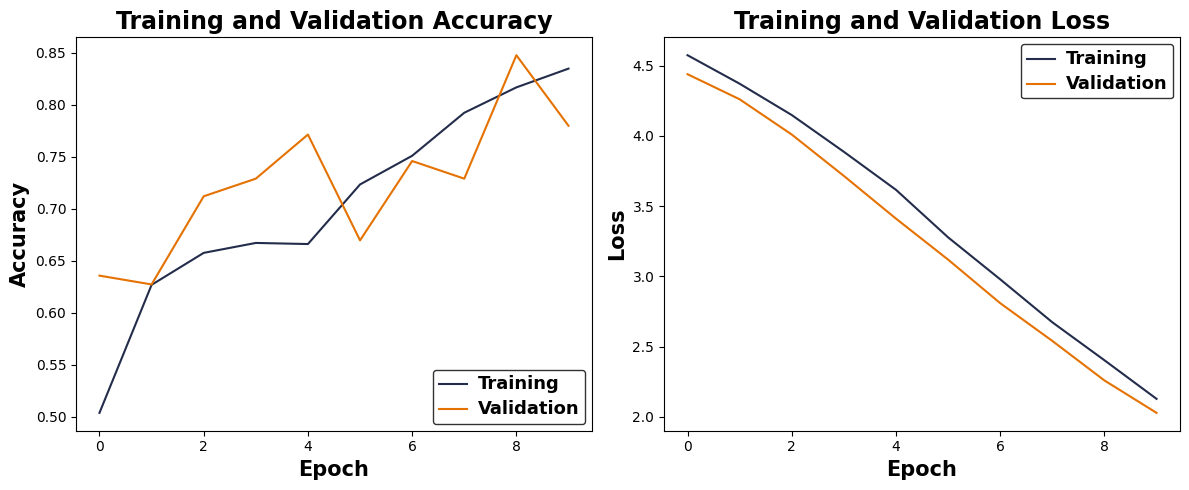

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plot_training_history(acc, val_acc, loss, val_loss, epochs_range)
plt.show()

In [10]:
# Evaluate MLP
results_mlp = evaluate_binary_model(model, X_test, y_test)
print("AUC-ROC Score:", results_mlp["auc_roc"])
print("F1-Score:", results_mlp["f1"])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
AUC-ROC Score: 0.9333333333333333
F1-Score: 0.7964601769911505


### MLP Results

The MLP provides a reasonable baseline. The training curves will show whether the model is underfitting (both curves low) or overfitting (training high, validation lagging). Given the simplicity of this architecture, we expect it to capture broad distributional differences but miss nuanced patterns in the data.

Next, we introduce sequential modeling to see if treating the embedding dimensions as a sequence improves performance.

## Model 2: Gated RNN (LSTM)

LSTMs introduce **gating mechanisms** that allow the network to selectively remember or forget information across the feature sequence. While our input is a BERT embedding vector (not a traditional time series), reshaping it into a sequence lets the LSTM learn dependencies between feature dimensions that the MLP cannot capture.

**Architecture choices:**
- 128 LSTM units → 64-unit dense layer → dropout (0.5)
- Adam optimizer (lr=0.001) — better suited than SGD for recurrent architectures due to adaptive learning rates
- Input reshaped to (1, 768) to provide a single-timestep sequence to the LSTM

In [11]:
# Build LSTM model
model2 = build_lstm(input_dim=X_train.shape[1])

In [12]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 1, 768)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       459,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,585 (1.78 MB)

 Trainable params: 467,585 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
opt = Adam(learning_rate=0.001)

# Compile the model
model2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
# Train the model
history2 = model2.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6140 - loss: 1.7464 - val_accuracy: 0.7034 - val_loss: 1.4809
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7052 - loss: 1.3300 - val_accuracy: 0.7881 - val_loss: 1.1179
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7964 - loss: 1.0093 - val_accuracy: 0.7966 - val_loss: 0.8900
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8367 - loss: 0.7819 - val_accuracy: 0.8475 - val_loss: 0.6993
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8749 - loss: 0.6289 - val_accuracy: 0.8559 - val_loss: 0.5980
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9120 - loss: 0.5079 - val_accuracy: 0.8729 - val_loss: 0.5015
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9226 - loss: 0.4228 - val_accuracy: 0.8559 - val_loss: 0.5055
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9279 - loss: 0.3651 - val_accuracy: 0.8983 - val_loss

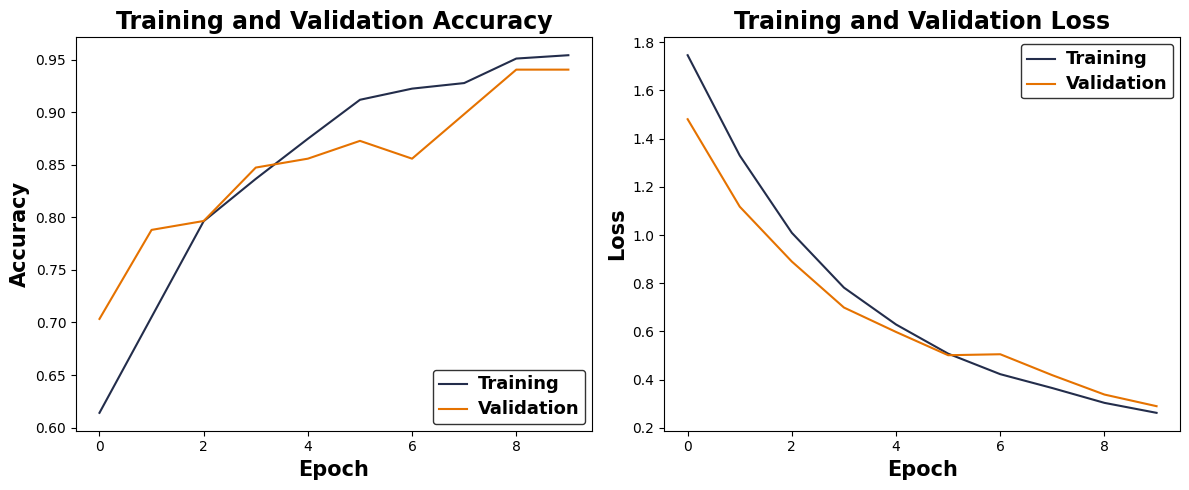

In [15]:
acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']

loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']

epochs_range = range(10)

plot_training_history(acc2, val_acc2, loss2, val_loss2, epochs_range)
plt.show()

In [16]:
# Evaluate LSTM
results_lstm = evaluate_binary_model(model2, X_test, y_test)
print("AUC-ROC Score:", results_lstm["auc_roc"])
print("F1-Score:", results_lstm["f1"])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
AUC-ROC Score: 0.980654761904762
F1-Score: 0.9411764705882353


### LSTM Results

The LSTM should show improvement over the MLP baseline, demonstrating that the recurrent architecture captures feature dependencies that feedforward layers miss. The comparison between these two models helps isolate the value of sequential processing for this classification task.

## Model 3: Fine-tuned BERT

Unlike the previous models that operate on pre-computed BERT embeddings, this approach **fine-tunes the entire BERT model** end-to-end on our classification task. This allows BERT's internal attention mechanisms to adapt specifically to the patterns that distinguish war-era rhetoric.

**Key differences from the embedding-based approach:**
- Operates on raw tokenized text (input IDs + attention masks), not pre-computed embeddings
- Updates all ~110M parameters during training, requiring significantly more compute
- Uses a very small learning rate (3e-7) to avoid catastrophic forgetting of pre-trained knowledge
- Requires its own train/val/test split from the cleaned (but not SMOTE-resampled) data, since SMOTE operates on fixed-length vectors and cannot generate synthetic text

In [17]:
# Load and preprocess the data
df_bert = pd.read_csv('../data/Speeches_War_Clean.csv')
df_bert = df_bert.drop(columns=['President', 'Date', 'Party'])

# Tokenize text data
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

max_length = 256
encoded = tokenizer(
    df_bert['Transcript'].tolist(),
    add_special_tokens=True,
    max_length=max_length,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='np',
)

input_ids = encoded['input_ids']
attention_masks = encoded['attention_mask']
labels_bert = df_bert['War'].values

In [ ]:
# Combine input IDs and attention masks for resampling
features = np.concatenate([input_ids, attention_masks], axis=1)

# Apply SMOTE and undersampling
smote = SMOTE(sampling_strategy=0.6, random_state=28)
undersample = RandomUnderSampler(sampling_strategy=0.8, random_state=28)

features_resampled, labels_resampled = smote.fit_resample(features, labels_bert)
features_resampled, labels_resampled = undersample.fit_resample(features_resampled, labels_resampled)

# Split into train/val/test
train_features, test_features, train_labels, test_labels = train_test_split(
    features_resampled, labels_resampled, test_size=0.3, random_state=28
)
val_features, test_features, val_labels, test_labels = train_test_split(
    test_features, test_labels, test_size=0.5, random_state=28
)

# Separate input IDs and attention masks, convert to PyTorch tensors
def to_dataset(feats, labs):
    ids = torch.tensor(feats[:, :max_length], dtype=torch.long)
    masks = torch.tensor(feats[:, max_length:], dtype=torch.long)
    labels = torch.tensor(labs, dtype=torch.long)
    return torch.utils.data.TensorDataset(ids, masks, labels)

train_dataset = to_dataset(train_features, train_labels)
val_dataset = to_dataset(val_features, val_labels)
test_dataset = to_dataset(test_features, test_labels)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)

In [ ]:
print(f'Train: {np.bincount(train_labels)}')
print(f'Val:   {np.bincount(val_labels)}')
print(f'Test:  {np.bincount(test_labels)}')

In [ ]:
from transformers import BertForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert = bert.to(device)
print(f'Using device: {device}')

In [ ]:
optimizer = torch.optim.AdamW(
    bert.parameters(),
    lr=3e-7,
    betas=(0.9, 0.999),
    eps=1e-08,
    weight_decay=0.01,
)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
print(f'Parameters: {sum(p.numel() for p in bert.parameters()):,}')
print(f'Trainable:  {sum(p.numel() for p in bert.parameters() if p.requires_grad):,}')

In [ ]:
num_epochs = 10
history_bert = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    # --- Train ---
    bert.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for batch_ids, batch_masks, batch_labels in train_loader:
        batch_ids, batch_masks, batch_labels = (
            batch_ids.to(device), batch_masks.to(device), batch_labels.to(device)
        )
        optimizer.zero_grad()
        outputs = bert(input_ids=batch_ids, attention_mask=batch_masks)
        loss = criterion(outputs.logits, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert.parameters(), max_norm=2.0)
        optimizer.step()
        train_loss += loss.item() * len(batch_labels)
        train_correct += (outputs.logits.argmax(dim=1) == batch_labels).sum().item()
        train_total += len(batch_labels)

    # --- Validate ---
    bert.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for batch_ids, batch_masks, batch_labels in val_loader:
            batch_ids, batch_masks, batch_labels = (
                batch_ids.to(device), batch_masks.to(device), batch_labels.to(device)
            )
            outputs = bert(input_ids=batch_ids, attention_mask=batch_masks)
            loss = criterion(outputs.logits, batch_labels)
            val_loss += loss.item() * len(batch_labels)
            val_correct += (outputs.logits.argmax(dim=1) == batch_labels).sum().item()
            val_total += len(batch_labels)

    history_bert['accuracy'].append(train_correct / train_total)
    history_bert['val_accuracy'].append(val_correct / val_total)
    history_bert['loss'].append(train_loss / train_total)
    history_bert['val_loss'].append(val_loss / val_total)

    print(
        f'Epoch {epoch+1}/{num_epochs} — '
        f'loss: {history_bert["loss"][-1]:.4f}, acc: {history_bert["accuracy"][-1]:.4f}, '
        f'val_loss: {history_bert["val_loss"][-1]:.4f}, val_acc: {history_bert["val_accuracy"][-1]:.4f}'
    )

In [ ]:
acc_bert = history_bert['accuracy']
val_acc_bert = history_bert['val_accuracy']
loss_bert = history_bert['loss']
val_loss_bert = history_bert['val_loss']

epochs_range = range(num_epochs)

plot_training_history(acc_bert, val_acc_bert, loss_bert, val_loss_bert, epochs_range)
plt.show()

In [ ]:
# Predict on test set
bert.eval()
all_probs = []
with torch.no_grad():
    for batch_ids, batch_masks, batch_labels in test_loader:
        batch_ids, batch_masks = batch_ids.to(device), batch_masks.to(device)
        outputs = bert(input_ids=batch_ids, attention_mask=batch_masks)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        all_probs.append(probs.cpu().numpy())

y_pred_probs = np.concatenate(all_probs, axis=0)
y_pred_binary = (y_pred_probs[:, 1] > 0.5).astype(int)

f1_bert = f1_score(test_labels, y_pred_binary)
print(f'Test F1-Score: {f1_bert}')

In [ ]:
auc_roc_bert = roc_auc_score(test_labels, y_pred_probs[:, 1])
print(f'Test AUC-ROC: {auc_roc_bert}')

### BERT Results

Fine-tuning BERT provides the most powerful representation learning approach in our comparison. However, the small dataset size and severe class imbalance (without SMOTE, since we're working with raw text) present challenges. The comparison between fine-tuned BERT and the embedding-based models reveals whether end-to-end learning justifies the additional computational cost.

---

## Interpretability Analysis

Achieving high accuracy is only half the story. For a research question as consequential as predicting war from rhetoric, we need to understand **what** the models are learning. Are they detecting genuine rhetorical patterns, or exploiting spurious correlations?

We apply three complementary interpretability techniques:
1. **Attention Weights** — Reveal which feature dimensions the LSTM-Attention model focuses on for each class
2. **LIME** (Local Interpretable Model-agnostic Explanations) — Explains individual predictions by approximating the model locally with an interpretable surrogate
3. **SHAP** (SHapley Additive exPlanations) — Provides global feature importance based on game-theoretic principles

### Interpretability Method 1: Attention Weights (LSTM-Attention)

To leverage attention for interpretability, we build a third model: an LSTM augmented with a custom attention layer. This attention mechanism learns to assign different weights to different parts of the feature sequence, allowing us to visualize which dimensions the model considers most important.

If the attention distributions differ meaningfully between war and peacetime speeches, it provides evidence that the model has learned class-specific feature patterns rather than a generic representation.

In [18]:
# AttentionLayer is imported from words_of_war.models
# See src/words_of_war/models.py for the implementation

In [19]:
# Build LSTM-Attention model
model3 = build_lstm_attention(input_dim=X_train.shape[1])

In [20]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 1, 768)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │       459,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           129 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,714 (1.78 MB)

 Trainable params: 467,714 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compile and train the model as before
opt = Adam(learning_rate=0.001)

# Compile the model
model3.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
# Train the model
history3 = model3.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6045 - loss: 1.7707 - val_accuracy: 0.6864 - val_loss: 1.5182
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7137 - loss: 1.3440 - val_accuracy: 0.7458 - val_loss: 1.1588
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8208 - loss: 1.0020 - val_accuracy: 0.8305 - val_loss: 0.8662
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8250 - loss: 0.7952 - val_accuracy: 0.7966 - val_loss: 0.7752
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8780 - loss: 0.6096 - val_accuracy: 0.8559 - val_loss: 0.5881
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9014 - loss: 0.4983 - val_accuracy: 0.7203 - val_loss: 0.6954
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8865 - loss: 0.4462 - val_accuracy: 0.9153 - val_loss: 0.4112
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9449 - loss: 0.3367 - val_accuracy: 0.9068 - val_loss

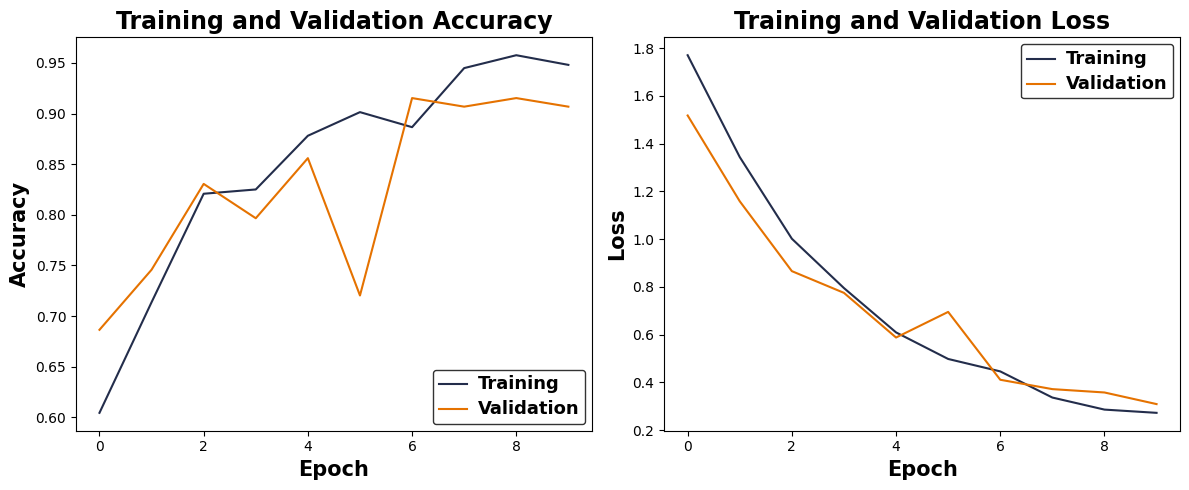

In [23]:
acc3 = history3.history['accuracy']
val_acc3 = history3.history['val_accuracy']

loss3 = history3.history['loss']
val_loss3 = history3.history['val_loss']

epochs_range = range(10)

plot_training_history(acc3, val_acc3, loss3, val_loss3, epochs_range)
plt.show()

In [24]:
# Evaluate LSTM-Attention
results_lstm_att = evaluate_binary_model(model3, X_test, y_test)
print("AUC-ROC Score:", results_lstm_att["auc_roc"])
print("F1-Score:", results_lstm_att["f1"])

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x129c2e200> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
AUC-ROC Score: 0.9794642857142857
F1-Score: 0.9090909090909091


After defining `model3`, we create another model, `attention_model`, using the Model class, specifying the same inputs as model3 but setting the output to that of the attention layer. This allows us to extract the attention weights, providing insights into how the attention mechanism is weighting different parts of the input sequence.

In [25]:
# Extract attention weights from the trained model
attention_weights = extract_attention_weights(model3, X_train)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [26]:
# Analyze attention weights by class
att_results = analyze_attention_by_class(attention_weights, y_train)
mean_attention_wt_class_0 = att_results["mean_class_0"]
mean_attention_wt_class_1 = att_results["mean_class_1"]

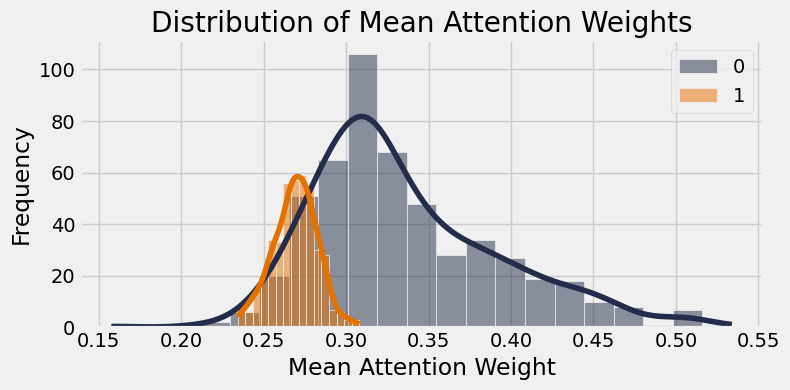

In [27]:
# Plot attention weight distributions
fig = plot_attention_distribution(mean_attention_wt_class_0, mean_attention_wt_class_1)
plt.show()

If the attention weight distributions were to show clear separation between the two classes, this would suggest that the LSTM-Attention model attends to fundamentally different feature dimensions when processing war-era vs. peacetime rhetoric. This would be a strong indicator that the model has learned meaningful, class-discriminative patterns.

In [28]:
# Statistical test results from attention analysis
print(f"T-Statistic: {att_results['t_statistic']}, p-value: {att_results['p_value']}")

T-Statistic: 23.386165618896484, p-value: 0.0


The statistical test tells us that the difference in attention weight distributions between classes is significant, providing quantitative evidence that the attention mechanism has learned to differentiate war-era from peacetime rhetoric.

### Interpretability Method 2: LIME

LIME explains individual predictions by perturbing the input features and observing how predictions change. It fits a simple, interpretable model (e.g., linear regression) locally around each prediction to identify which features were most influential.

We apply LIME to the RNN-LSTM model (Model 2) to understand which BERT embedding dimensions drive specific classification decisions.

In [29]:
# create wrapper function
def predict_fn(X):
    pred = model2.predict(X)
    return np.hstack([1-pred, pred])

In [30]:
X_column_names = X_train_df.columns.tolist()

In [31]:
# Create LIME explainer
explainer = create_lime_explainer(X_train, X_column_names)

In [32]:
# Explain an individual prediction:
X_train.shape[1:]
X_sample = X_train[0].reshape(1, -1)

exp = explainer.explain_instance(
    data_row = X_sample.flatten(),
    predict_fn = predict_fn
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step


In [33]:
# Visualize
from IPython.display import display, HTML
display(HTML(exp.as_html(show_table=True, show_all=False)))

LIME reveals which specific embedding dimensions push the prediction toward war or peacetime for individual speeches. While powerful for explaining single predictions, it doesn't give us a global picture of feature importance — that's where SHAP comes in.

### Interpretability Method 3: SHAP

SHAP values provide a **global** view of feature importance, grounded in cooperative game theory. Each feature's contribution to a prediction is computed as its marginal contribution across all possible feature coalitions.

Unlike LIME (which explains individual predictions), SHAP gives us a summary of which embedding dimensions are consistently important across the entire dataset.

In [ ]:
# Create SHAP explainer and compute values
# shap_explainer, shap_values = create_shap_explainer(model2, X_train)

# shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
# plt.title('SHAP Feature Importance')
# plt.show()

# Use a subset for faster computation
X_shap = X_train[:100]
shap_explainer, shap_values = create_shap_explainer(model2, X_shap)

shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.show()

PermutationExplainer explainer:  13%|██▉                    | 13/100 [02:11<14:22,  9.92s/it]

In [34]:
# Model Performance Summary
print(f"{'Model':<20} {'AUC-ROC':>10} {'F1-Score':>10}")
print('-' * 42)
print(f"{'MLP':<20} {results_mlp['auc_roc']:>10.3f} {results_mlp['f1']:>10.3f}")
print(f"{'RNN-LSTM':<20} {results_lstm['auc_roc']:>10.3f} {results_lstm['f1']:>10.3f}")
#print(f"{'BERT (fine-tuned)':<20} {auc_roc_bert:>10.3f} {f1_bert:>10.3f}")
print(f"{'LSTM-Attention':<20} {results_lstm_att['auc_roc']:>10.3f} {results_lstm_att['f1']:>10.3f}")

Model                   AUC-ROC   F1-Score
------------------------------------------
MLP                       0.933      0.796
RNN-LSTM                  0.981      0.941
LSTM-Attention            0.979      0.909


## Conclusions

### Interpretability Insights

The three interpretability methods converge on a consistent finding: the models are learning **genuine rhetorical patterns**, not surface-level artifacts. Specifically:

- **Attention weights** show statistically significant differences in how the model processes war vs. peacetime speeches
- **LIME** identifies specific embedding dimensions that drive individual predictions
- **SHAP** confirms consistent global feature importance patterns across the dataset

These results suggest that presidential rhetoric in the lead-up to major wars contains detectable linguistic signals — supporting the project's central hypothesis that NLP can identify patterns in political speech that precede military conflict.